# Monte Carlo Simulation Example: Annual Credit Card Spending

This section demonstrates a simple but powerful application of **Monte Carlo simulation** to model uncertainty in annual credit-card spending over a 12-month period. Rather than assuming a single fixed outcome, Monte Carlo methods generate **thousands of simulated scenarios**, allowing us to observe the full distribution of possible annual spending outcomes.

---

### Objective

We simulate total credit-card spending over one year under two different assumptions:

#### Experiment A — Normal Variability
- Monthly spending fluctuates around a typical average.
- Variability is driven by standard month-to-month randomness.
- No extreme shocks are included.
- This represents a “business-as-usual” environment.

#### Experiment B — With Black Swan Events
- Most months behave normally.
- However, there is a small probability of a rare, extreme spending spike.
- These “black-swan” months represent unexpected large expenses (e.g., medical emergency, major travel, urgent repairs).
- This introduces **fat tails** into the distribution.

--- 

### What This Demonstrates

This example highlights key risk concepts:

- The difference between **normal risk** and **tail risk**
- How rare events significantly shift percentile outcomes
- Why relying only on averages can be misleading
- The importance of distributional analysis

---

### Outputs

The simulation produces:

- Two separate histograms (one for each experiment)
- A percentile summary table including key metrics such as:
  - Mean
  - Median
  - 5th percentile (downside scenario)
  - 95th percentile (upside/tail scenario)

By comparing the two experiments, we can clearly observe how introducing rare extreme events affects the **shape, dispersion, and tail behaviour** of total annual spending. This mirrors real-world financial modelling, where stress testing and tail-risk analysis are critical for understanding exposure beyond “normal” expectations.

Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ace_tools_open as tools

In [2]:
np.random.seed(42)

### Defining our Monte Carlo Simulation Function

**Monte Carlo Function: `monte_carlo_annual_spend`**

This function simulates **annual total credit-card spending** using a Monte Carlo approach. It generates thousands of possible yearly outcomes by modelling monthly spending as a random process.

---

> Function Purpose: To produce a distribution of possible annual spending outcomes under:
1. Normal month-to-month variability  
2. Optional rare “black-swan” shock months  

The output is an array of simulated annual totals, which can then be analysed using histograms, percentiles, or risk metrics.

---

#### Step-by-Step Logic

##### 1️⃣ Generate Monthly Spending

Monthly spending is drawn from a normal distribution:

$$
X_{m} \sim \mathcal{N}(\mu, \sigma^2)
$$

Where:
- $\mu$ = `monthly_mean`
- $\sigma$ = `monthly_sd`
- Shape = `(n_sims, months)`

This creates a matrix of simulated monthly values for each scenario. To prevent unrealistic outcomes, the negative spending values are clipped to zero:

$$
X_{m} = \max(0, X_{m})
$$


##### 2️⃣ Optional Black Swan Adjustment

If `include_black_swan=True`, each simulated month has a small probability of experiencing a shock. For each month:

$$
P(\text{shock}) = \text{black\_swan\_prob}
$$

If a shock occurs:

$$
X_{m} = X_{m} \times \text{black\_swan\_impact}
$$

For example:
- `black_swan_prob = 0.02` → 2% chance per month  
- `black_swan_impact = 0.2` → 80% drop in that month  

This introduces **tail risk** and creates a non-normal distribution.


##### 3️⃣ Compute Annual Total

Annual spending per simulation:

$$
\text{Annual Total} = \sum_{m=1}^{12} X_{m}
$$

This results in:

- One total value per simulation
- Output array of length `n_sims`

---

## Key Parameters

| Parameter | Meaning |
|------------|----------|
| `n_sims` | Number of Monte Carlo simulations |
| `months` | Number of months in each simulation |
| `monthly_mean` | Average monthly spending |
| `monthly_sd` | Monthly spending volatility |
| `include_black_swan` | Whether rare shocks are included |
| `black_swan_prob` | Probability of a shock in any month |
| `black_swan_impact` | Multiplicative impact of the shock |

---

#### Conceptual Insight

- Without black swans → distribution tends toward normal (via Central Limit Theorem).
- With black swans → distribution becomes skewed and fat-tailed.
- Demonstrates how rare events materially change percentile outcomes and risk exposure.

This simple structure mirrors real-world financial modelling used in portfolio risk, stress testing, and tail-risk analysis.


In [3]:
def monte_carlo_annual_spend(n_sims=10000, months=12, monthly_mean=1000, monthly_sd=200, include_black_swan=False, black_swan_prob=0.02, black_swan_impact=0.2):
  """
  Returns an array of simulated annual total spends.
  - include_black_swan: if True, each month has black_swan_prob chance of being multiplied by black_swan_impact.
    (e.g., black_swan_impact=0.2 means an 80% drop for that month)
  """
  # draw monthly spends: shape (n_sims, months)
  monthly = np.random.normal(loc=monthly_mean, scale=monthly_sd, size=(n_sims, months))
  # ensure no negative spending
  monthly = np.clip(monthly, a_min=0, a_max=None)
  
  if include_black_swan:
    # Draw uniform random numbers to decide black swan months
    flags = np.random.rand(n_sims, months) < black_swan_prob
    # Apply impact
    monthly = np.where(flags, monthly * black_swan_impact, monthly)
  
  annual_totals = monthly.sum(axis=1)
  return annual_totals

Let us run our simulations

In [4]:
# Run simulations
n_sims = 10000
annual_normal = monte_carlo_annual_spend(n_sims=n_sims, include_black_swan=False)
annual_with_black = monte_carlo_annual_spend(n_sims=n_sims, include_black_swan=True, black_swan_prob=0.02, black_swan_impact=0.2)

# Compute percentiles and summary statistics
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
summary = pd.DataFrame({
  'percentile': percentiles,
  'normal': np.percentile(annual_normal, percentiles),
  'with_black_swan': np.percentile(annual_with_black, percentiles)
})

summary['normal'] = summary['normal'].round(2)
summary['with_black_swan'] = summary['with_black_swan'].round(2)

In [5]:
# Display the summary table to the user
tools.display_dataframe_to_user("Monte Carlo Annual Spend Percentiles", summary)

Monte Carlo Annual Spend Percentiles


Loading ITables v2.5.2 from the internet... (need help?)


Plotting the simulation for ease of visualisation

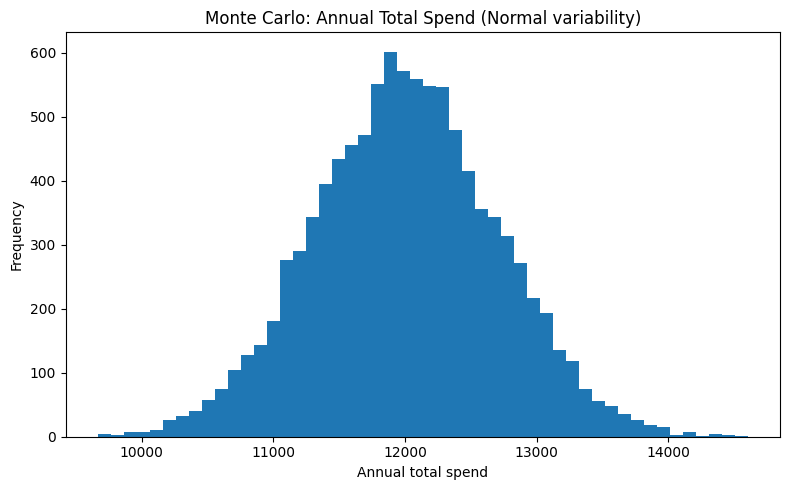

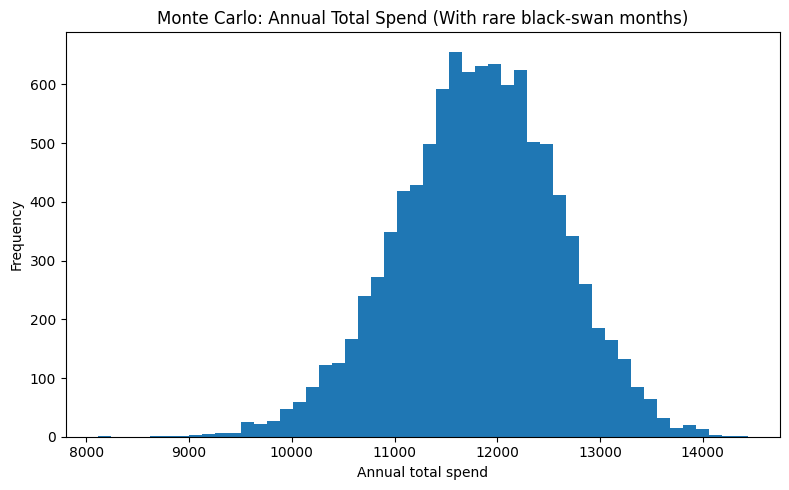

Numeric Summary: Normal vs With Black Swan


Loading ITables v2.5.2 from the internet... (need help?)


In [6]:
# Plot histogram for normal simulation
plt.figure(figsize=(8,5))
plt.hist(annual_normal, bins=50)
plt.title("Monte Carlo: Annual Total Spend (Normal variability)")
plt.xlabel("Annual total spend")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot histogram for simulation with rare black-swan months
plt.figure(figsize=(8,5))
plt.hist(annual_with_black, bins=50)
plt.title("Monte Carlo: Annual Total Spend (With rare black-swan months)")
plt.xlabel("Annual total spend")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Print quick numeric summary in the notebook output as well
summary_stats = pd.DataFrame({
  'stat': ['mean', 'std', '5th', '50th', '95th'],
  'normal': [annual_normal.mean(), annual_normal.std(), np.percentile(annual_normal,5), np.percentile(annual_normal,50), np.percentile(annual_normal,95)],
  'with_black_swan': [annual_with_black.mean(), annual_with_black.std(), np.percentile(annual_with_black,5), np.percentile(annual_with_black,50), np.percentile(annual_with_black,95)]
}).round(2)

tools.display_dataframe_to_user("Numeric Summary: Normal vs With Black Swan", summary_stats)

#### Quick takeaways from this run:

Introducing rare, deep drops increases the distribution's spread (std) and shifts lower-tail percentiles down (e.g., the 5th percentile falls more), even if the median moves only a little.
Monte Carlo makes these tail effects visible and measurable so you can build stress tests or capital buffers accordingly.